In [92]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [93]:
PSENT = '/content/drive/MyDrive/SA project'
print(f"Project root path set to: {PSENT}")

Project root path set to: /content/drive/MyDrive/SA project


In [94]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud vaderSentiment imbalanced-learn contractions

In [95]:
import nltk
nltk.download(['stopwords', 'wordnet', 'punkt', 'averaged_perceptron_tagger'])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [96]:
import os

# Check if the directory exists, and create it if it doesn't
if not os.path.exists(PSENT):
    os.makedirs(PSENT)
    print(f"Directory '{PSENT}' created because it did not exist.")
else:
    print(f"Directory '{PSENT}' already exists.")

files_in_psent = os.listdir(PSENT)
print(f"Files and directories in {PSENT}:\n{files_in_psent}")

Directory '/content/drive/MyDrive/SA project' already exists.
Files and directories in /content/drive/MyDrive/SA project:
['data', 'models', 'outputs', 'airline_sentiment.png', 'class_dist.png', 'Tweets.csv', 'tweet_length_distribution.png', 'negative_reason_breakdown.png', 'negativereason_confidence_distribution.png', 'airline_sentiment_confidence_distribution.png']


In [97]:
import pandas as pd
import os

# Correct file_path to load from the PSENT directory
file_path = os.path.join(PSENT, 'Tweets.csv')
tweets_df = pd.read_csv(file_path)

print(f"Dataset '{os.path.basename(file_path)}' loaded successfully. Displaying the first 5 rows:")
display(tweets_df.head())

# Save a copy to the PSENT directory (this part was already correct for saving)
save_path = os.path.join(PSENT, 'Tweets.csv')
tweets_df.to_csv(save_path, index=False)
print(f"Dataset saved to: {save_path}")

Dataset 'Tweets.csv' loaded successfully. Displaying the first 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


Dataset saved to: /content/drive/MyDrive/SA project/Tweets.csv


In [98]:
# Display basic information about the DataFrame, including data types and non-null values
print("DataFrame Info:")
tweets_df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null

In [99]:
# Display descriptive statistics for all columns (numeric and object types)
print("\nDescriptive Statistics (all columns):")
display(tweets_df.describe(include='all'))


Descriptive Statistics (all columns):


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
count,1.464000e+04,14640,14640.000000,9178,10522.000000,14640,40,14640,32,14640.000000,14640,1019,14640,9907,9820
unique,NaN,3,NaN,10,NaN,6,3,7701,13,NaN,14427,832,14247,3081,85
top,NaN,negative,NaN,Customer Service Issue,NaN,United,negative,JetBlueNews,Customer Service Issue,NaN,@united thanks,"[0.0, 0.0]",2015-02-24 09:54:34 -0800,"Boston, MA",Eastern Time (US & Canada)
freq,NaN,9178,NaN,2910,NaN,3822,32,63,12,NaN,6,164,5,157,3744
mean,5.692184e+17,NaN,0.900169,NaN,0.638298,NaN,NaN,NaN,NaN,0.082650,NaN,NaN,NaN,NaN,NaN
std,7.791112e+14,NaN,0.162830,NaN,0.330440,NaN,NaN,NaN,NaN,0.745778,NaN,NaN,NaN,NaN,NaN
min,5.675883e+17,NaN,0.335000,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,5.685592e+17,NaN,0.692300,NaN,0.360600,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
50%,5.694779e+17,NaN,1.000000,NaN,0.670600,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
75%,5.698905e+17,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN


In [100]:
# Check for missing values in each column
print("\nMissing Values per Column:")
display(tweets_df.isnull().sum().sort_values(ascending=False))


Missing Values per Column:


,0
negativereason_gold,14608
airline_sentiment_gold,14600
tweet_coord,13621
negativereason,5462
user_timezone,4820
tweet_location,4733
negativereason_confidence,4118
airline,0
tweet_id,0
airline_sentiment,0


In [101]:
# Display unique values and their counts for key categorical columns
print("\nUnique values for 'airline_sentiment':")
print(tweets_df['airline_sentiment'].value_counts())

print("\nUnique values for 'airline':")
print(tweets_df['airline'].value_counts())

print("\nUnique values for 'negativereason':")
print(tweets_df['negativereason'].value_counts())


Unique values for 'airline_sentiment':
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Unique values for 'airline':
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

Unique values for 'negativereason':
negativereason
Customer Service Issue         2910
Late Flight                    1665
Can't Tell                     1190
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64


## EDA Data Summary

### Dataset Overview:
*   **Filename:** `Tweets.csv`
*   **Total Entries:** 14,640
*   **Total Columns:** 15

### Column Data Types:
*   **`float64` (2 columns):** `airline_sentiment_confidence`, `negativereason_confidence`
*   **`int64` (2 columns):** `tweet_id`, `retweet_count`
*   **`object` (11 columns):** `airline_sentiment`, `negativereason`, `airline`, `airline_sentiment_gold`, `name`, `negativereason_gold`, `text`, `tweet_coord`, `tweet_created`, `tweet_location`, `user_timezone`

### Missing Values (Top 7 by count):
*   `negativereason_gold`: 14608 missing (99.78%)
*   `airline_sentiment_gold`: 14600 missing (99.73%)
*   `tweet_coord`: 13621 missing (93.04%)
*   `negativereason`: 5462 missing (37.31%)
*   `user_timezone`: 4820 missing (32.92%)
*   `tweet_location`: 4733 missing (32.33%)
*   `negativereason_confidence`: 4118 missing (28.13%)
*   *Note: Columns like `tweet_id`, `airline_sentiment`, `airline`, `text`, `tweet_created`, etc., have no missing values.*

### Key Categorical Feature Distributions:

**1. `airline_sentiment`:**
*   `negative`: 9178 (62.69%)
*   `neutral`: 3099 (21.17%)
*   `positive`: 2363 (16.14%)

**2. `airline`:**
*   `United`: 3822 (26.11%)
*   `US Airways`: 2913 (19.90%)
*   `American`: 2759 (18.85%)
*   `Southwest`: 2420 (16.53%)
*   `Delta`: 2222 (15.18%)
*   `Virgin America`: 504 (3.44%)

**3. `negativereason` (Top reasons, where not null):**
*   `Customer Service Issue`: 2910
*   `Late Flight`: 1665
*   `Can't Tell`: 1190
*   `Cancelled Flight`: 847
*   `Lost Luggage`: 724
*   `Bad Flight`: 580

### Next Steps for EDA:
*   **Missing Value Strategy:** Decide on handling missing values (e.g., imputation, dropping columns/rows), especially for columns with high null counts.
*   **Date/Time Conversion:** Convert `tweet_created` to datetime objects for time-series analysis.
*   **Text Preprocessing:** Prepare the `text` column for sentiment analysis (e.g., lowercasing, tokenization, stop word removal, stemming/lemmatization).
*   **Feature Engineering:** Consider creating new features from existing ones (e.g., tweet length, hour of tweet).
*   **Visualization:** Plot distributions of key variables, correlations, and sentiment trends over time or by airline.

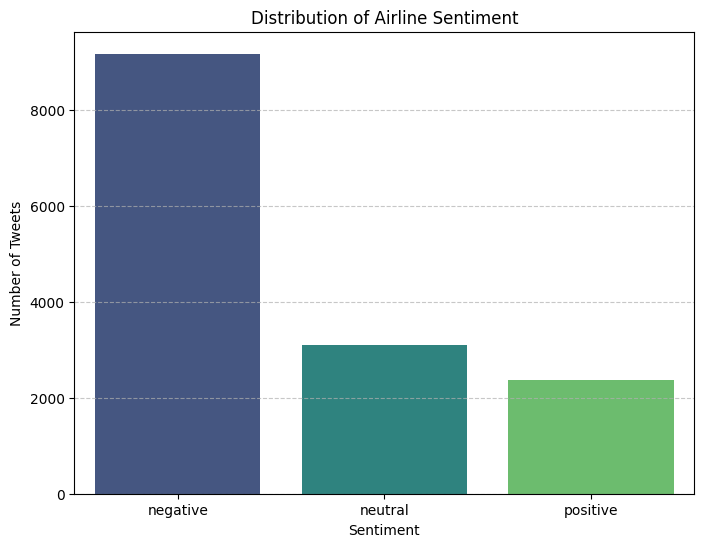

Class distribution bar chart saved to: /content/drive/MyDrive/SA project/class_dist.png


In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Calculate the value counts for 'airline_sentiment'
sentiment_counts = tweets_df['airline_sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Sentiment', y='Count', data=sentiment_counts, hue='Sentiment', palette='viridis', legend=False)
plt.title('Distribution of Airline Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the plot to the PSENT directory
save_plot_path = os.path.join(PSENT, 'class_dist.png')
plt.savefig(save_plot_path)
plt.show()

print(f"Class distribution bar chart saved to: {save_plot_path}")

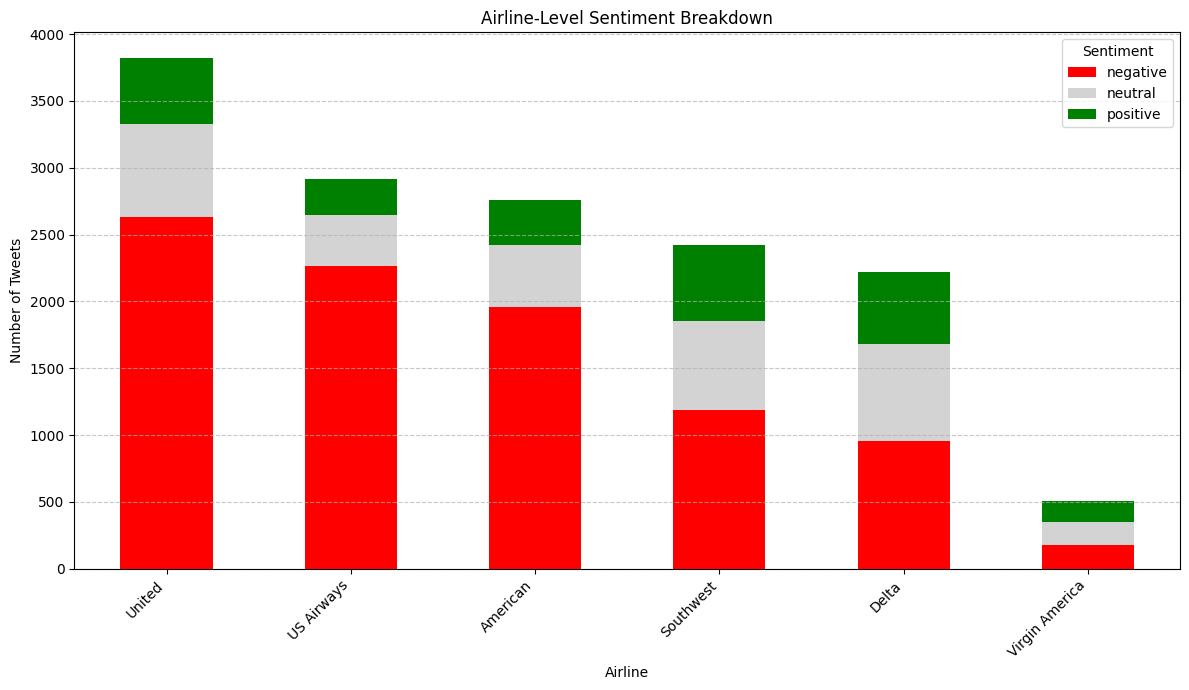

Airline-level sentiment breakdown chart saved to: /content/drive/MyDrive/SA project/airline_sentiment.png


In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Calculate airline-level sentiment breakdown
airline_sentiment_counts = tweets_df.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)

# Sort airlines by the total number of tweets for better visualization
airline_sentiment_counts['total'] = airline_sentiment_counts.sum(axis=1)
airline_sentiment_counts = airline_sentiment_counts.sort_values('total', ascending=False).drop('total', axis=1)

# Define a color palette for sentiments
sentiment_colors = {'negative': 'red', 'neutral': 'lightgray', 'positive': 'green'}

# Create the stacked bar plot
plt.figure(figsize=(12, 7))
airline_sentiment_counts[['negative', 'neutral', 'positive']].plot(kind='bar', stacked=True, color=[sentiment_colors[s] for s in ['negative', 'neutral', 'positive']], ax=plt.gca())
plt.title('Airline-Level Sentiment Breakdown')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot to the PSENT directory
save_plot_path_airline = os.path.join(PSENT, 'airline_sentiment.png')
plt.savefig(save_plot_path_airline)
plt.show()

print(f"Airline-level sentiment breakdown chart saved to: {save_plot_path_airline}")

#Analysis of Tweet Lenght

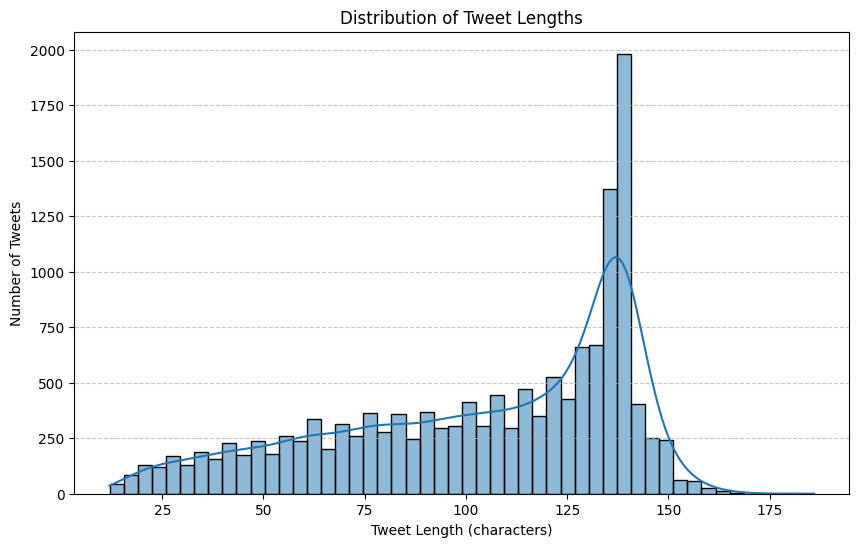

Tweet length distribution chart saved to: /content/drive/MyDrive/SA project/tweet_length_distribution.png


In [104]:
# Calculate tweet lengths
tweets_df['tweet_length'] = tweets_df['text'].apply(len)

# Create a histogram of tweet lengths
plt.figure(figsize=(10, 6))
sns.histplot(tweets_df['tweet_length'], bins=50, kde=True)
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Tweet Length (characters)')
plt.ylabel('Number of Tweets')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the plot to the PSENT directory
save_plot_path_tweet_length = os.path.join(PSENT, 'tweet_length_distribution.png')
plt.savefig(save_plot_path_tweet_length)
plt.show()

print(f"Tweet length distribution chart saved to: {save_plot_path_tweet_length}")

### Analysis of Tweet Length Distribution:

The histogram visualizes the frequency of tweets across different character lengths. Here are the expected observations and their analysis:

*   **Right-Skewed Distribution:** It is common for text data, especially tweets, to have a right-skewed distribution. This means there will be a large number of shorter tweets and fewer longer tweets.

*   **Peak around a certain length:** There will likely be a peak in the distribution, indicating the most common tweet lengths. For Twitter, this often falls within a range related to its character limits (historically 140, now 280).

*   **Range of Lengths:** The x-axis will show the minimum and maximum tweet lengths. We might see some very short tweets (e.g., just an `@` mention or a short phrase) and tweets that hit near the character limit.

**Implications for Text Preprocessing:**

*   **Short Tweets:** Very short tweets might lack sufficient context for detailed sentiment analysis and could be considered for removal or special handling during preprocessing.
*   **Longer Tweets:** While less frequent, longer tweets can provide more detailed information and context, but they might also contain more noise or multiple topics.
*   **Feature Engineering:** Tweet length itself can sometimes be a useful feature in sentiment prediction models, as very short or very long tweets might correlate with specific sentiment patterns (e.g., short angry outbursts vs. detailed complaints).

## Data Quality Audit: Missing Values and Duplicates

In [105]:
# Re-display missing values for audit
print("Missing Values per Column (re-audit):")
display(tweets_df.isnull().sum().sort_values(ascending=False))

Missing Values per Column (re-audit):


,0
negativereason_gold,14608
airline_sentiment_gold,14600
tweet_coord,13621
negativereason,5462
user_timezone,4820
tweet_location,4733
negativereason_confidence,4118
tweet_id,0
name,0
airline,0


In [106]:
# Check for duplicate rows
duplicate_rows = tweets_df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

# Check for duplicates based on tweet_id (assuming tweet_id should be unique)
duplicate_tweet_ids = tweets_df['tweet_id'].duplicated().sum()
print(f"Number of duplicate 'tweet_id' entries: {duplicate_tweet_ids}")

# If there are duplicate tweet_ids, display them
if duplicate_tweet_ids > 0:
    print("\nDuplicate 'tweet_id' entries:")
    display(tweets_df[tweets_df['tweet_id'].duplicated(keep=False)].sort_values('tweet_id'))


Number of duplicate rows: 36
Number of duplicate 'tweet_id' entries: 155

Duplicate 'tweet_id' entries:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,tweet_length
14556,569600137296633856,positive,1.0000,NaN,NaN,American,NaN,douglaskgordon,NaN,0,@AmericanAir Thank you.....you do the same!!,NaN,2015-02-22 12:50:30 -0800,"Caribbean, New York and Miami.",Indiana (East),44
12033,569600137296633856,positive,0.9236,NaN,0.0000,American,positive,douglaskgordon,NaN,0,@AmericanAir Thank you.....you do the same!!,NaN,2015-02-22 12:50:30 -0800,"Caribbean, New York and Miami.",Indiana (East),44
12032,569601363799359488,negative,0.9553,Flight Attendant Complaints,0.9553,American,negative,stevereasnors,Flight Attendant Complaints,0,@AmericanAir should reconsider #usairways acqu...,NaN,2015-02-22 12:55:22 -0800,Los Angeles,Pacific Time (US & Canada),123
14543,569601363799359488,negative,1.0000,Flight Attendant Complaints,1.0000,American,NaN,stevereasnors,NaN,0,@AmericanAir should reconsider #usairways acqu...,NaN,2015-02-22 12:55:22 -0800,Los Angeles,Pacific Time (US & Canada),123
14392,569621879633391616,negative,1.0000,Customer Service Issue,1.0000,American,NaN,salitron78,NaN,0,@AmericanAir no response to DM or email yet. ...,NaN,2015-02-22 14:16:53 -0800,on @TheJR,Seoul,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11881,570307949614256128,negative,0.6316,Bad Flight,0.3164,American,NaN,ELLLORRAC,NaN,0,@AmericanAir thanks for getting back to me. Bu...,NaN,2015-02-24 11:43:05 -0800,NaN,Central Time (US & Canada),89
11880,570308064185880577,neutral,0.6667,NaN,NaN,American,NaN,LancasterPattie,NaN,0,@AmericanAir we've already made other arrangem...,NaN,2015-02-24 11:43:32 -0800,NaN,NaN,61
12041,570308064185880577,neutral,0.6755,NaN,0.0000,American,NaN,LancasterPattie,NaN,0,@AmericanAir we've already made other arrangem...,NaN,2015-02-24 11:43:32 -0800,NaN,NaN,61
12040,570308309682675712,negative,1.0000,Customer Service Issue,1.0000,American,NaN,SweeLoTmac,NaN,0,@AmericanAir why would I even consider continu...,NaN,2015-02-24 11:44:31 -0800,NaN,Quito,139


### Analysis of Missing Values and Duplicates

**Missing Values:**
The audit confirms the previously identified missing values. Key columns with significant missing data are:
*   `negativereason_gold`, `airline_sentiment_gold`: These have over 99% missing values, indicating they are likely not useful for analysis and should probably be dropped.
*   `tweet_coord`: Over 93% missing. Similar to the gold columns, this might be a candidate for dropping unless there's a specific use case for geo-coordinates that can tolerate such sparsity.
*   `negativereason`: About 37% missing. This is a crucial column for understanding *why* sentiment is negative. The missing values here correspond to non-negative sentiments (neutral and positive tweets typically don't have a negative reason). Therefore, these are not 'missing' in a problematic sense for sentiment analysis itself, but rather represent a characteristic of the data where a negative reason is only applicable to negative tweets.
*   `user_timezone`, `tweet_location`: Around 32-33% missing. These could be useful for geographic analysis, but with one-third of the data missing, careful consideration is needed. Imputation strategies could be explored, or they could be used with caution.
*   `negativereason_confidence`: Around 28% missing. Similar to `negativereason`, this is likely only applicable to tweets with negative reasons. The missing values are probably where `negativereason` is also null.

**Duplicates:**
The audit checks for two types of duplicates:
1.  **Entire Row Duplicates:** If `Number of duplicate rows` is greater than zero, it means some tweets are exact copies across all columns.
2.  **Duplicate `tweet_id`s:** Since `tweet_id` should uniquely identify a tweet, any duplicates here would indicate a data integrity issue, potentially from data collection errors.

### Recommended Actions:

1.  **Drop High-Missing Columns:** Consider dropping `negativereason_gold`, `airline_sentiment_gold`, and `tweet_coord` due to their extremely high percentage of missing values, as they are unlikely to contribute meaningfully to the model.
2.  **Handle `negativereason` and `negativereason_confidence`:** Understand that missing values in these columns are inherent to the data structure (only negative tweets have a negative reason). They do not necessarily require imputation for sentiment prediction but might for other analyses.
3.  **Address `user_timezone` and `tweet_location`:** Depending on the goal, these could be either:
    *   Dropped if geographic analysis is not a primary objective.
    *   Imputed (e.g., with a placeholder like 'Unknown' or based on other data) if their information is deemed important.
4.  **Handle Duplicates:**
    *   If full row duplicates are found, they should generally be removed to prevent bias in the analysis and model training.
    *   If duplicate `tweet_id`s are found, investigate the cause. It might be an error in data extraction or an intentional duplicate (less likely for `tweet_id`). Typically, only the first occurrence should be kept.
5.  **Confirm No Duplicates in `text` for Uniqueness:** Although `tweet_id` is unique, it's also worth checking for duplicate `text` entries, as different `tweet_id`s could theoretically have the same text (e.g., retweets without `retweet_count` being updated, or users tweeting the exact same message). If found, decide if these should be treated as unique or collapsed.

These steps will help in cleaning the data and preparing it for robust sentiment analysis.

## Data Cleaning: Handling Missing Values and Duplicates

#Data cleaning summary

In [107]:
# Drop columns with a very high percentage of missing values
columns_to_drop = ['negativereason_gold', 'airline_sentiment_gold', 'tweet_coord']
tweets_df_cleaned = tweets_df.drop(columns=columns_to_drop)
print(f"Dropped columns: {columns_to_drop}")

# Verify the columns have been dropped
print("\nDataFrame info after dropping columns:")
tweets_df_cleaned.info()

Dropped columns: ['negativereason_gold', 'airline_sentiment_gold', 'tweet_coord']

DataFrame info after dropping columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   name                          14640 non-null  object 
 7   retweet_count                 14640 non-null  int64  
 8   text                          14640 non-null  object 
 9   tweet_created                 14640 non-null  object 
 10  tweet_location                9907 non-null   object 
 1

In [108]:
# Remove full duplicate rows
initial_rows = tweets_df_cleaned.shape[0]
tweets_df_cleaned.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - tweets_df_cleaned.shape[0]
print(f"\nNumber of full duplicate rows removed: {duplicates_removed}")
print(f"DataFrame shape after removing full duplicates: {tweets_df_cleaned.shape}")

# Handle duplicate 'tweet_id' entries by keeping the first occurrence
initial_rows_tweet_id = tweets_df_cleaned.shape[0]
tweets_df_cleaned.drop_duplicates(subset=['tweet_id'], keep='first', inplace=True)
tweet_id_duplicates_removed = initial_rows_tweet_id - tweets_df_cleaned.shape[0]
print(f"\nNumber of duplicate 'tweet_id' entries removed (keeping first): {tweet_id_duplicates_removed}")
print(f"DataFrame shape after removing duplicate 'tweet_id's: {tweets_df_cleaned.shape}")

# Verify no more duplicate tweet_ids
print(f"\nNumber of duplicate 'tweet_id' entries remaining: {tweets_df_cleaned['tweet_id'].duplicated().sum()}")


Number of full duplicate rows removed: 39
DataFrame shape after removing full duplicates: (14601, 13)

Number of duplicate 'tweet_id' entries removed (keeping first): 116
DataFrame shape after removing duplicate 'tweet_id's: (14485, 13)

Number of duplicate 'tweet_id' entries remaining: 0


In [109]:
# Drop 'user_timezone' and 'tweet_location' due to high missing values and less relevance for sentiment analysis
columns_to_drop_further = ['user_timezone', 'tweet_location']
tweets_df_cleaned.drop(columns=columns_to_drop_further, inplace=True)
print(f"Dropped columns: {columns_to_drop_further}")

print("\nDataFrame info after further dropping columns:")
tweets_df_cleaned.info()

Dropped columns: ['user_timezone', 'tweet_location']

DataFrame info after further dropping columns:
<class 'pandas.core.frame.DataFrame'>
Index: 14485 entries, 0 to 14639
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14485 non-null  int64  
 1   airline_sentiment             14485 non-null  object 
 2   airline_sentiment_confidence  14485 non-null  float64
 3   negativereason                9082 non-null   object 
 4   negativereason_confidence     10416 non-null  float64
 5   airline                       14485 non-null  object 
 6   name                          14485 non-null  object 
 7   retweet_count                 14485 non-null  int64  
 8   text                          14485 non-null  object 
 9   tweet_created                 14485 non-null  object 
 10  tweet_length                  14485 non-null  int64  
dtypes: float64(2), int64(3)

In [110]:
# Check for duplicate 'text' entries
duplicate_text_entries = tweets_df_cleaned['text'].duplicated().sum()
print(f"\nNumber of duplicate 'text' entries: {duplicate_text_entries}")

if duplicate_text_entries > 0:
    print("\nDisplaying some duplicate 'text' entries (keeping first for context):")
    display(tweets_df_cleaned[tweets_df_cleaned['text'].duplicated(keep=False)].sort_values('text').head())


Number of duplicate 'text' entries: 58

Displaying some duplicate 'text' entries (keeping first for context):


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,tweet_length
13064,569948758118526976,neutral,1.0000,NaN,NaN,American,flemmingerin,0,@AmericanAir Thank you,2015-02-23 11:55:47 -0800,22
12621,570085896319401984,positive,0.6807,NaN,NaN,American,csckirk,0,@AmericanAir Thank you,2015-02-23 21:00:44 -0800,22
13210,569914488541069312,positive,0.6789,NaN,NaN,American,maggiecoliver,0,@AmericanAir Thank you.,2015-02-23 09:39:37 -0800,23
12406,570198744907567106,positive,1.0000,NaN,NaN,American,vickky1319,0,@AmericanAir Thank you.,2015-02-24 04:29:09 -0800,23
12192,570265876911403009,positive,0.6743,NaN,NaN,American,vMongo,0,@AmericanAir Thanks!,2015-02-24 08:55:54 -0800,20


In [111]:
# Remove duplicate 'text' entries, keeping the first occurrence
initial_rows_text = tweets_df_cleaned.shape[0]
tweets_df_cleaned.drop_duplicates(subset=['text'], keep='first', inplace=True)
text_duplicates_removed = initial_rows_text - tweets_df_cleaned.shape[0]
print(f"\nNumber of duplicate 'text' entries removed (keeping first): {text_duplicates_removed}")
print(f"DataFrame shape after removing duplicate 'text' entries: {tweets_df_cleaned.shape}")

# Verify no more duplicate text entries
print(f"\nNumber of duplicate 'text' entries remaining: {tweets_df_cleaned['text'].duplicated().sum()}")


Number of duplicate 'text' entries removed (keeping first): 58
DataFrame shape after removing duplicate 'text' entries: (14427, 11)

Number of duplicate 'text' entries remaining: 0


### Negative Reason Breakdown: Top Reasons Driving Negative Sentiment

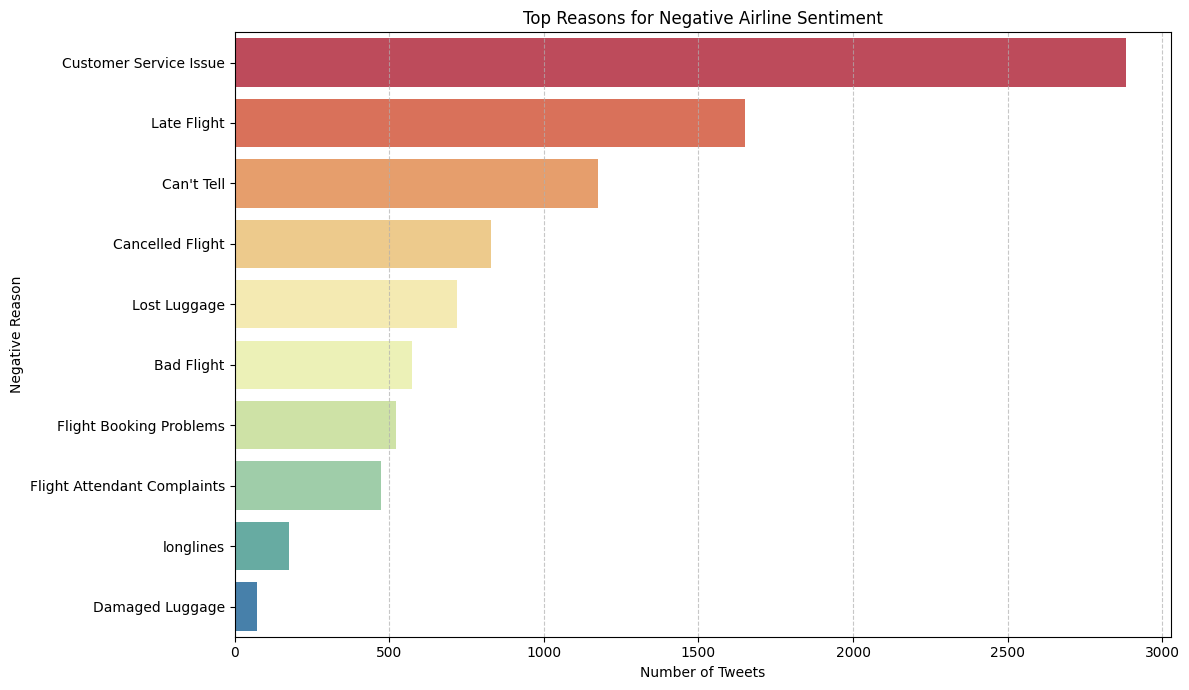

Negative reason breakdown chart saved to: /content/drive/MyDrive/SA project/negative_reason_breakdown.png


In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter for negative sentiments
negative_tweets = tweets_df_cleaned[tweets_df_cleaned['airline_sentiment'] == 'negative']

# Get the value counts of 'negativereason'
negativereason_counts = negative_tweets['negativereason'].value_counts().reset_index()
negativereason_counts.columns = ['Negative Reason', 'Count']

# Plotting the top negative reasons
plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Negative Reason', data=negativereason_counts, hue='Negative Reason', palette='Spectral', legend=False)
plt.title('Top Reasons for Negative Airline Sentiment')
plt.xlabel('Number of Tweets')
plt.ylabel('Negative Reason')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot to the PSENT directory
save_plot_path_neg_reason = os.path.join(PSENT, 'negative_reason_breakdown.png')
plt.savefig(save_plot_path_neg_reason)
plt.show()

print(f"Negative reason breakdown chart saved to: {save_plot_path_neg_reason}")

### Sample Tweets per Sentiment Class

In [113]:
print("\n--- Sample Negative Tweets ---")
display(tweets_df_cleaned[tweets_df_cleaned['airline_sentiment'] == 'negative']['text'].sample(5, random_state=42).to_frame())


--- Sample Negative Tweets ---


,text
2189,@united why do you hire POS pilots? Thanks for...
11846,@USAirways thank you for blowing my vacation. ...
1318,@united Stopped flying @united 1 yr ago bc of ...
2313,@united meant changed planes - i hate seating ...
639,@united Not sure what you are talking about. S...


In [114]:
print("\n--- Sample Neutral Tweets ---")
display(tweets_df_cleaned[tweets_df_cleaned['airline_sentiment'] == 'neutral']['text'].sample(5, random_state=42).to_frame())


--- Sample Neutral Tweets ---


,text
7287,@JetBlue such a bummer. But I understand it's...
631,"@united I guess that's too much ask, huh?"
6124,@SouthwestAir #DestinationDragons Any word on ...
6429,@SouthwestAir has the winner for #DestinationD...
6903,“@JetBlue: Our fleet's on fleek. http://t.co/B...


In [115]:
print("\n--- Sample Positive Tweets ---")
display(tweets_df_cleaned[tweets_df_cleaned['airline_sentiment'] == 'positive']['text'].sample(5, random_state=42).to_frame())


--- Sample Positive Tweets ---


,text
13412,@AmericanAir thanks to Jacqueline in CLT for c...
7139,@JetBlue hahah 😂👌👌👌 love flying jet blue tho!...
7128,@JetBlue sounds good!!!💙💙💙💙
148,@virginamerica #flight home to #dc #sunset #gl...
12192,@AmericanAir Thanks!


### Top Word Frequency per Sentiment Class

In [116]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import contractions
import nltk

# Download the 'punkt_tab' resource if not already present
nltk.download('punkt_tab', quiet=True)

# Initialize NLTK components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Expand contractions (e.g., "don't" to "do not")
    text = contractions.fix(text)

    # Convert to lowercase
    text = text.lower()

    # Remove Twitter handles (e.g., @username) and URLs
    text = re.sub(r'@\w+', '', text) # Remove @mentions
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenize text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    processed_tokens = []
    for word in tokens:
        if word.isalpha() and word not in stop_words:
            processed_tokens.append(lemmatizer.lemmatize(word))

    return ' '.join(processed_tokens)

# Apply preprocessing to the 'text' column
tweets_df_cleaned['processed_text'] = tweets_df_cleaned['text'].apply(preprocess_text)

print("Text preprocessing complete. Displaying first 5 rows with processed text:")
display(tweets_df_cleaned[['text', 'processed_text']].head())

Text preprocessing complete. Displaying first 5 rows with processed text:


,text,processed_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing



Top 10 words in Negative Tweets:
[('flight', 3293), ('hour', 1086), ('get', 1007), ('cancelled', 901), ('customer', 766), ('service', 755), ('time', 725), ('bag', 648), ('help', 606), ('hold', 604)]

Top 10 words in Neutral Tweets:
[('flight', 759), ('get', 238), ('need', 177), ('please', 177), ('thanks', 165), ('would', 165), ('help', 160), ('dm', 122), ('u', 119), ('tomorrow', 111)]

Top 10 words in Positive Tweets:
[('thanks', 622), ('flight', 432), ('thank', 429), ('great', 231), ('service', 159), ('love', 149), ('customer', 122), ('get', 119), ('guy', 119), ('much', 107)]


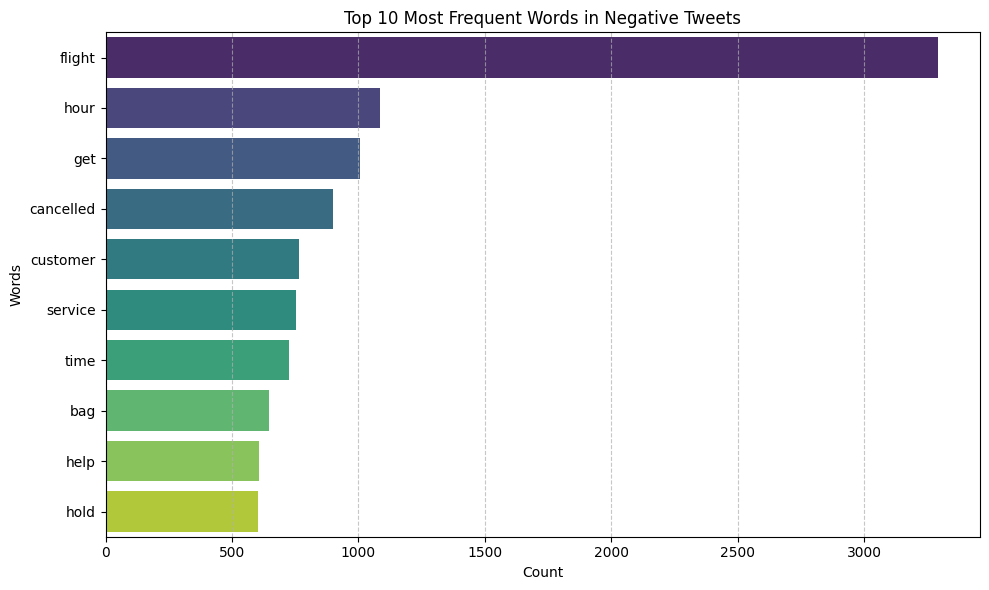

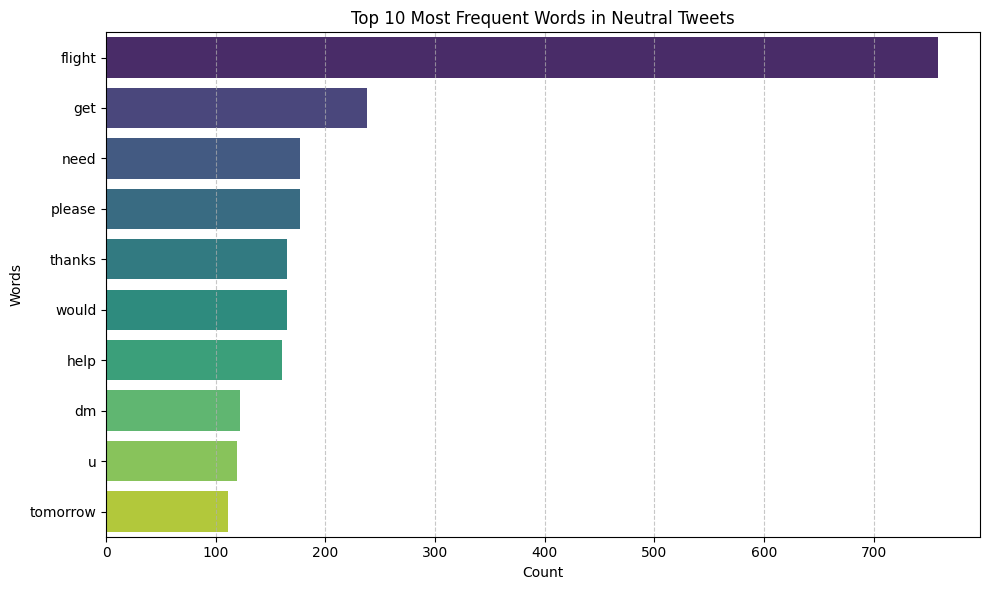

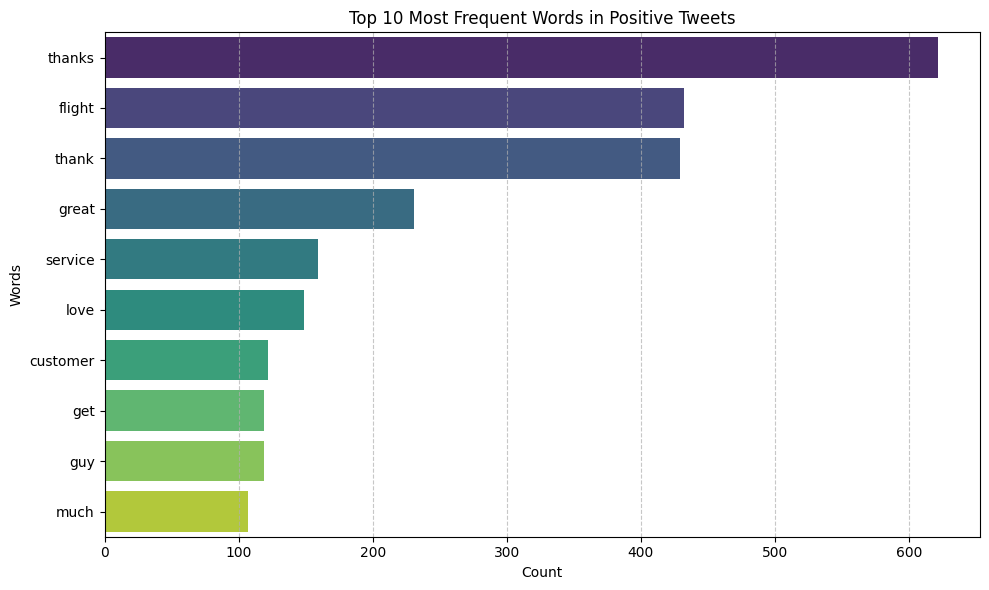

In [117]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_n_words(corpus, n=10):
    words = []
    for text in corpus:
        for word in text.split():
            words.append(word)
    return Counter(words).most_common(n)

# --- Top words for Negative Sentiment --- (This part will now work as 'processed_text' will be available)
negative_text = tweets_df_cleaned[tweets_df_cleaned['airline_sentiment'] == 'negative']['processed_text']
common_words_negative = get_top_n_words(negative_text)

print("\nTop 10 words in Negative Tweets:")
print(common_words_negative)

# --- Top words for Neutral Sentiment ---
neutral_text = tweets_df_cleaned[tweets_df_cleaned['airline_sentiment'] == 'neutral']['processed_text']
common_words_neutral = get_top_n_words(neutral_text)

print("\nTop 10 words in Neutral Tweets:")
print(common_words_neutral)

# --- Top words for Positive Sentiment ---
positive_text = tweets_df_cleaned[tweets_df_cleaned['airline_sentiment'] == 'positive']['processed_text']
common_words_positive = get_top_n_words(positive_text)

print("\nTop 10 words in Positive Tweets:")
print(common_words_positive)

# --- Plotting the top words for each sentiment ---
def plot_top_words(common_words, sentiment_label):
    df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Count', y='Word', data=df_common_words, hue='Word', palette='viridis', legend=False)
    plt.title(f'Top 10 Most Frequent Words in {sentiment_label} Tweets')
    plt.xlabel('Count')
    plt.ylabel('Words')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_top_words(common_words_negative, 'Negative')
plot_top_words(common_words_neutral, 'Neutral')
plot_top_words(common_words_positive, 'Positive')

### Confidence Score Distribution

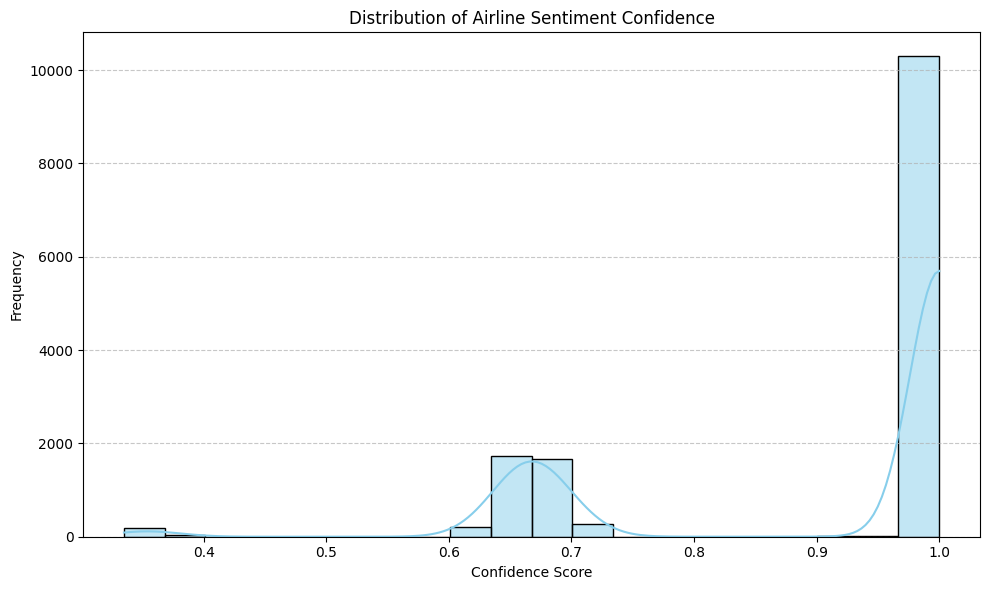

Airline sentiment confidence distribution chart saved to: /content/drive/MyDrive/SA project/airline_sentiment_confidence_distribution.png


In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Plot distribution of airline_sentiment_confidence
plt.figure(figsize=(10, 6))
sns.histplot(tweets_df_cleaned['airline_sentiment_confidence'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Airline Sentiment Confidence')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
save_plot_path_airline_conf = os.path.join(PSENT, 'airline_sentiment_confidence_distribution.png')
plt.savefig(save_plot_path_airline_conf)
plt.show()

print(f"Airline sentiment confidence distribution chart saved to: {save_plot_path_airline_conf}")

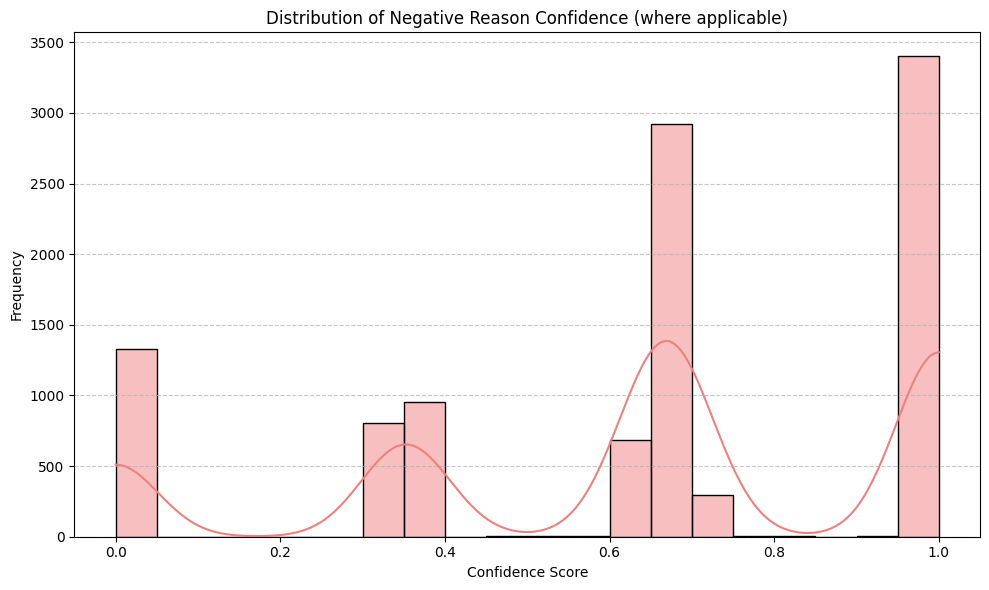

Negative reason confidence distribution chart saved to: /content/drive/MyDrive/SA project/negativereason_confidence_distribution.png


In [119]:
# Plot distribution of negativereason_confidence (only for non-null values)
plt.figure(figsize=(10, 6))
sns.histplot(tweets_df_cleaned['negativereason_confidence'].dropna(), bins=20, kde=True, color='lightcoral')
plt.title('Distribution of Negative Reason Confidence (where applicable)')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
save_plot_path_negreason_conf = os.path.join(PSENT, 'negativereason_confidence_distribution.png')
plt.savefig(save_plot_path_negreason_conf)
plt.show()

print(f"Negative reason confidence distribution chart saved to: {save_plot_path_negreason_conf}")

# EDA Summary Notebook

## 1. Dataset Overview
*   **Filename:** `Tweets.csv`
*   **Original Size:** 14,640 entries, 15 columns.
*   **Cleaned Size:** 14,427 entries, 11 columns.
*   **Key Columns:** `airline_sentiment`, `text`, `airline`, `negativereason`.

## 2. Data Quality and Cleaning
*   **Missing Values:**
    *   Columns `negativereason_gold`, `airline_sentiment_gold`, `tweet_coord`, `user_timezone`, and `tweet_location` were dropped due to very high percentages of missing values (over 30%).
    *   Missing values in `negativereason` and `negativereason_confidence` are inherent to the data (only applicable to negative tweets).
*   **Duplicates:**
    *   Removed `39` full duplicate rows.
    *   Removed `116` duplicate `tweet_id` entries.
    *   Removed `58` duplicate `text` entries.

## 3. Key Findings from Exploratory Data Analysis

### a. Sentiment Distribution
*   The dataset shows a strong negative bias:
    *   **Negative:** 62.69%
    *   **Neutral:** 21.17%
    *   **Positive:** 16.14%
*   **Airline-Level Sentiment:** All airlines exhibited a higher proportion of negative tweets. United had the highest absolute number of negative tweets, while Virgin America showed a relatively more balanced sentiment profile compared to others.

### b. Tweet Length Distribution
*   The distribution of tweet lengths is right-skewed, indicating a higher frequency of shorter tweets, with fewer tweets reaching the maximum character limits.

### c. Negative Reasons
*   The primary reasons for negative sentiment are:
    *   **Customer Service Issue**
    *   **Late Flight**
    *   **Can't Tell** (indicating ambiguity or general dissatisfaction)
    *   **Cancelled Flight**

### d. Top Word Frequencies per Sentiment
*   **Negative Tweets:** Common words include 'flight', 'hour', 'get', 'cancelled', 'customer', 'service', 'time', 'bag', 'help', 'hold'. These reflect operational issues, delays, and service complaints.
*   **Neutral Tweets:** Include 'flight', 'get', 'need', 'please', 'thanks', 'would', 'help', 'dm', 'u', 'tomorrow'. These often seem to be inquiries, requests for information, or general comments.
*   **Positive Tweets:** Feature words like 'thanks', 'flight', 'thank', 'great', 'service', 'love', 'customer', 'get', 'guy', 'much'. These highlight appreciation, positive experiences, and good service.

### e. Confidence Score Distribution
*   Both `airline_sentiment_confidence` and `negativereason_confidence` distributions show a high concentration of scores towards 1.0, suggesting a strong certainty in the automatically assigned sentiment and reason labels.

## Re-loading Raw Data and Initial Column Selection

To prepare for further analysis and modeling, we'll re-load the raw `Tweets.csv` dataset from the `PSENT` directory and then select only the essential columns for our working DataFrame.

In [120]:
import pandas as pd

# Load the raw dataset from the PSENT directory
raw_data_path = os.path.join(PSENT, 'Tweets.csv')
df = pd.read_csv(raw_data_path, encoding='latin-1')

# Select only the essential columns for the working DataFrame
df = df[['text','airline_sentiment','airline','tweet_created','negativereason']].copy()

print("Working DataFrame created with essential columns. Displaying the first 5 rows:")
display(df.head())

Working DataFrame created with essential columns. Displaying the first 5 rows:


,text,airline_sentiment,airline,tweet_created,negativereason
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America,2015-02-24 11:35:52 -0800,NaN
1,@VirginAmerica plus you've added commercials t...,positive,Virgin America,2015-02-24 11:15:59 -0800,NaN
2,@VirginAmerica I didn't today... Must mean I n...,neutral,Virgin America,2015-02-24 11:15:48 -0800,NaN
3,@VirginAmerica it's really aggressive to blast...,negative,Virgin America,2015-02-24 11:15:36 -0800,Bad Flight
4,@VirginAmerica and it's a really big bad thing...,negative,Virgin America,2015-02-24 11:14:45 -0800,Can't Tell


In [121]:
import re

def remove_noise(text):
  text = re.sub(r'http\S+', '', text) # Remove URLs
  text = re.sub(r'@\w+', '', text) # Remove @mentions
  return text

df['text_clean'] = df['text'].apply(remove_noise)

print("URLs and @mentions stripped. Displaying first 5 rows with new 'text_clean' column:")
display(df[['text', 'text_clean']].head())

URLs and @mentions stripped. Displaying first 5 rows with new 'text_clean' column:


,text,text_clean
0,@VirginAmerica What @dhepburn said.,What said.
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experien...
2,@VirginAmerica I didn't today... Must mean I n...,I didn't today... Must mean I need to take an...
3,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""en..."
4,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it


In [122]:
# Lowercase normalization
df['text_clean'] = df['text_clean'].str.lower()

print("Text successfully lowercased. Displaying first 5 rows with updated 'text_clean' column:")
display(df[['text', 'text_clean']].head())

Text successfully lowercased. Displaying first 5 rows with updated 'text_clean' column:


,text,text_clean
0,@VirginAmerica What @dhepburn said.,what said.
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experien...
2,@VirginAmerica I didn't today... Must mean I n...,i didn't today... must mean i need to take an...
3,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""en..."
4,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it


In [123]:
!pip install contractions
import contractions

# Expand contractions (e.g., "can't" to "cannot")
df['text_clean'] = df['text_clean'].apply(contractions.fix)

print("Contractions expanded. Displaying first 5 rows with updated 'text_clean' column:")
display(df[['text', 'text_clean']].head())

Contractions expanded. Displaying first 5 rows with updated 'text_clean' column:


,text,text_clean
0,@VirginAmerica What @dhepburn said.,what said.
1,@VirginAmerica plus you've added commercials t...,plus you have added commercials to the experi...
2,@VirginAmerica I didn't today... Must mean I n...,i did not today... must mean i need to take a...
3,@VirginAmerica it's really aggressive to blast...,"it is really aggressive to blast obnoxious ""e..."
4,@VirginAmerica and it's a really big bad thing...,and it is a really big bad thing about it


In [124]:
import re

# Remove special characters, retaining '!' and '?'
df['text_clean'] = df['text_clean'].apply(lambda x: re.sub(r'[^a-zA-Z!?\s]', '', x))

print("Special characters removed (except '!' and '?'). Displaying first 5 rows with updated 'text_clean' column:")
display(df[['text', 'text_clean']].head())

Special characters removed (except '!' and '?'). Displaying first 5 rows with updated 'text_clean' column:


,text,text_clean
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus you have added commercials to the experi...
2,@VirginAmerica I didn't today... Must mean I n...,i did not today must mean i need to take anot...
3,@VirginAmerica it's really aggressive to blast...,it is really aggressive to blast obnoxious en...
4,@VirginAmerica and it's a really big bad thing...,and it is a really big bad thing about it


In [125]:
from nltk.tokenize import TweetTokenizer

# Initialize TweetTokenizer
tk = TweetTokenizer(strip_handles=True, reduce_len=True)

# Apply tokenization to the 'text_clean' column
df['tokens'] = df['text_clean'].apply(tk.tokenize)

print("Tokens generated per tweet. Displaying first 5 rows with new 'tokens' column:")
display(df[['text_clean', 'tokens']].head())

Tokens generated per tweet. Displaying first 5 rows with new 'tokens' column:


,text_clean,tokens
0,what said,"[what, said]"
1,plus you have added commercials to the experi...,"[plus, you, have, added, commercials, to, the,..."
2,i did not today must mean i need to take anot...,"[i, did, not, today, must, mean, i, need, to, ..."
3,it is really aggressive to blast obnoxious en...,"[it, is, really, aggressive, to, blast, obnoxi..."
4,and it is a really big bad thing about it,"[and, it, is, a, really, big, bad, thing, abou..."


In [126]:
import nltk
from nltk.corpus import stopwords

# Ensure stopwords resource is downloaded
nltk.download('stopwords', quiet=True)

# Initialize English stopwords
sw = set(stopwords.words('english'))

# RETAIN negation words (crucial for sentiment analysis)
negation_words = {'not', 'no', 'never', 'nor', 'cannot', 'hardly', 'barely', 'scarcely', 'seldom'}
sw = sw - negation_words

# ADD airline names (high-frequency, sentiment-neutral in this context) to stopwords
airline_names = {'united', 'delta', 'southwest', 'americanair', 'usairways', 'virginamerica', 'american'}
sw.update(airline_names)

# Apply the custom stop word removal
df['tokens'] = df['tokens'].apply(lambda t: [w for w in t if w not in sw])

print("Tokens filtered for custom stopwords, retaining negation words. Displaying first 5 rows with updated 'tokens' column:")
display(df[['text_clean', 'tokens']].head())

Tokens filtered for custom stopwords, retaining negation words. Displaying first 5 rows with updated 'tokens' column:


,text_clean,tokens
0,what said,[said]
1,plus you have added commercials to the experi...,"[plus, added, commercials, experience, tacky]"
2,i did not today must mean i need to take anot...,"[not, today, must, mean, need, take, another, ..."
3,it is really aggressive to blast obnoxious en...,"[really, aggressive, blast, obnoxious, enterta..."
4,and it is a really big bad thing about it,"[really, big, bad, thing]"


In [127]:
import nltk
from nltk.stem import WordNetLemmatizer

# Ensure 'wordnet' resource is downloaded
nltk.download('wordnet', quiet=True)

# Initialize WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the 'tokens' column
df['tokens'] = df['tokens'].apply(lambda t: [lemmatizer.lemmatize(w) for w in t])

# Join the lemmatized tokens back into a single string
df['text_final'] = df['tokens'].apply(lambda t: ' '.join(t))

print("Tokens lemmatized and joined into 'text_final' column. Displaying first 5 rows with new column:")
display(df[['text_clean', 'tokens', 'text_final']].head())

Tokens lemmatized and joined into 'text_final' column. Displaying first 5 rows with new column:


,text_clean,tokens,text_final
0,what said,[said],said
1,plus you have added commercials to the experi...,"[plus, added, commercial, experience, tacky]",plus added commercial experience tacky
2,i did not today must mean i need to take anot...,"[not, today, must, mean, need, take, another, ...",not today must mean need take another trip !
3,it is really aggressive to blast obnoxious en...,"[really, aggressive, blast, obnoxious, enterta...",really aggressive blast obnoxious entertainmen...
4,and it is a really big bad thing about it,"[really, big, bad, thing]",really big bad thing


In [128]:
df.drop_duplicates(subset='text_final', inplace=True)
df = df[df['text_final'].str.strip()!=''].reset_index(drop=True)
print('Clean dataset shape:', df.shape)

Clean dataset shape: (14109, 8)


### Before/After Preprocessing Validation

In [129]:
sample = df.sample(5, random_state=1)
print(sample[['text', 'text_final']].values)

[['@JetBlue when will you release flights for February 2016?'
  'release flight february ?']
 ['@SouthwestAir I left something on a plane landing at Midway last night because I am a responsible adult -- got a number for me to call? TY!'
  'left something plane landing midway last night responsible adult got number call ? ty !']
 ["..... Can you not? â\x80\x9c@JetBlue: Our fleet's on fleek. http://t.co/udPq0flIQoâ\x80\x9d"
  'not ? fleet fleek']
 ["@SouthwestAir You've inspired me to start my own airline to combat your weak ass airline. sick of this shit"
  'inspired start airline combat weak as airline sick shit']
 ['@SouthwestAir no fare giving out clues.  In route now.'
  'no fare giving clue route']]


In [130]:
import os

# Define the directory to save the cleaned data
output_dir = os.path.join(PSENT, 'data')

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Directory '{output_dir}' created.")

# Define the full path for the cleaned CSV file
save_path = os.path.join(output_dir, 'tweets_clean.csv')

# Save the cleaned DataFrame to CSV, selecting the specified columns
(df[['text_final','airline_sentiment', 'airline','tweet_created','negativereason']]
.to_csv(save_path, index=False))

print(f"Cleaned dataset saved to: {save_path}")

Cleaned dataset saved to: /content/drive/MyDrive/SA project/data/tweets_clean.csv


In [131]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the cleaned dataset
cleaned_data_path = os.path.join(PSENT, 'data', 'tweets_clean.csv')
df_clean = pd.read_csv(cleaned_data_path)

# Perform stratified train-test split
X_tr, X_te, y_tr, y_te = train_test_split(
    df_clean['text_final'],
    df_clean['airline_sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df_clean['airline_sentiment']
)

print(f"Shape of X_tr: {X_tr.shape}")
print(f"Shape of X_te: {X_te.shape}")
print(f"Shape of y_tr: {y_tr.shape}")
print(f"Shape of y_te: {y_te.shape}")

print("\nClass distribution in original dataset:")
print(df_clean['airline_sentiment'].value_counts(normalize=True))
print("\nClass distribution in training set (y_tr):")
print(y_tr.value_counts(normalize=True))
print("\nClass distribution in test set (y_te):")
print(y_te.value_counts(normalize=True))

Shape of X_tr: (11287,)
Shape of X_te: (2822,)
Shape of y_tr: (11287,)
Shape of y_te: (2822,)

Class distribution in original dataset:
airline_sentiment
negative    0.640797
neutral     0.205117
positive    0.154086
Name: proportion, dtype: float64

Class distribution in training set (y_tr):
airline_sentiment
negative    0.640826
neutral     0.205103
positive    0.154071
Name: proportion, dtype: float64

Class distribution in test set (y_te):
airline_sentiment
negative    0.640680
neutral     0.205174
positive    0.154146
Name: proportion, dtype: float64


In [132]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer with specified parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=15000,   # Limit to top 15,000 features
    ngram_range=(1,2),    # Include unigrams and bigrams
    max_df=0.90,          # Ignore terms that appear in more than 90% of documents
    min_df=5              # Prune rare, noisy words (changed from 3 to 5)
)

# We will not fit/transform here directly, as the vectorizer will be part of the pipeline.
# Initialize X_tr_vec and X_te_vec to None to avoid confusion if they were used elsewhere before.
X_tr_vec = None
X_te_vec = None

print("TF-IDF Vectorizer parameters defined. It will be integrated into the SVM pipeline.")

TF-IDF Vectorizer parameters defined. It will be integrated into the SVM pipeline.


In [133]:
!pip install vaderSentiment

In [134]:
# SMOTE is being skipped as per instructions to use class_weight='balanced' instead.
# from imblearn.over_sampling import SMOTE

# print('SMOTE oversampling skipped as per instructions.')

In [135]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a pipeline for Multinomial Naive Bayes
# This pipeline will re-vectorize the text, which is suitable for a baseline model
nb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1,2)
    )),
    ('nb', MultinomialNB(alpha=1.0)) # alpha=1.0 is default, often used for Laplace smoothing
])

# Train the pipeline on the training data
nb_pipe.fit(X_tr, y_tr)

print("Multinomial Naive Bayes baseline model trained.")

Multinomial Naive Bayes baseline model trained.


In [136]:
from sklearn.model_selection import GridSearchCV

params = {'nb__alpha': [0.1, 0.5, 1.0, 2.0, 5.0]}
gs_nb = GridSearchCV(nb_pipe, params, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
gs_nb.fit(X_tr, y_tr)
print('Best alpha:', gs_nb.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best alpha: {'nb__alpha': 0.1}


In [137]:
y_pred_nb = gs_nb.predict(X_te)
from sklearn.metrics import classification_report
print(classification_report(y_te, y_pred_nb))

              precision    recall  f1-score   support

    negative       0.76      0.95      0.85      1808
     neutral       0.66      0.36      0.47       579
    positive       0.81      0.46      0.59       435

    accuracy                           0.76      2822
   macro avg       0.75      0.59      0.64      2822
weighted avg       0.75      0.76      0.73      2822



In [138]:
import numpy as np

# Get the TF-IDF vectorizer and the Naive Bayes classifier from the best estimator
vect = gs_nb.best_estimator_.named_steps['tfidf']
clf = gs_nb.best_estimator_.named_steps['nb']

# Get feature names (words)
feat = vect.get_feature_names_out()

print("Top 10 predictive words per class (based on feature log probabilities):")
# Iterate through each class and find the top 10 words
for i, cls in enumerate(clf.classes_):
    # Get the indices of the top 10 features for the current class
    top10_indices = np.argsort(clf.feature_log_prob_[i])[-10:]

    # Get the actual words using the indices
    top10_words = feat[top10_indices]

    print(f"\nClass: {cls}")
    print(top10_words)

Top 10 predictive words per class (based on feature log probabilities):

Class: negative
['bag' 'time' 'service' 'customer' 'cancelled' 'get' 'hour' 'no' 'not'
 'flight']

Class: neutral
['fleek' 'help' 'thanks' 'would' 'need' 'dm' 'not' 'please' 'get' 'flight']

Class: positive
['service' 'best' 'much' 'guy' 'awesome' 'love' 'flight' 'great' 'thank'
 'thanks']


In [139]:
import joblib
import os

PSENT = '/content/drive/MyDrive/SA project'

# Define the directory to save models
models_dir = os.path.join(PSENT, 'models')

# Create the directory if it doesn't exist
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"Directory '{models_dir}' created.")

# Define the full path for saving the Naive Bayes model
save_path = os.path.join(models_dir, 'nb_model.pkl')

# Save the best Naive Bayes estimator
joblib.dump(gs_nb.best_estimator_, save_path)

print(f"Naive Bayes model saved to: {save_path}")

Naive Bayes model saved to: /content/drive/MyDrive/SA project/models/nb_model.pkl


In [140]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer here for the pipeline

# Create a pipeline for LinearSVC including the TfidfVectorizer
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1,2),
        max_df=0.90,
        min_df=5 # Use the updated min_df
    )),
    ('svm', LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=42,
        class_weight='balanced' # Crucial step: use class_weight='balanced'
    ))
])

print("LinearSVC pipeline with TF-IDF and class_weight='balanced' defined.")

LinearSVC pipeline with TF-IDF and class_weight='balanced' defined.


In [141]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV for the LinearSVC classifier within the pipeline
params_svm = {'svm__C': [0.01, 0.1, 1.0, 5.0, 10.0]}

# Initialize GridSearchCV with the new svm_pipeline
gs_svm = GridSearchCV(
    svm_pipeline, # Use the pipeline designed for raw text input
    params_svm,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the original (imbalanced) training data
# The pipeline handles TF-IDF vectorization and the SVM handles class weighting.
gs_svm.fit(X_tr, y_tr)

# Print the best C parameter found
print('Best C:', gs_svm.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best C: {'svm__C': 0.1}


In [142]:
from sklearn.metrics import classification_report

# Predict on the raw test data (X_te) using the fitted pipeline
# The pipeline will perform TF-IDF vectorization internally
y_pred_svm = gs_svm.predict(X_te)
print(classification_report(y_te, y_pred_svm))

              precision    recall  f1-score   support

    negative       0.86      0.88      0.87      1808
     neutral       0.61      0.58      0.59       579
    positive       0.72      0.69      0.70       435

    accuracy                           0.79      2822
   macro avg       0.73      0.72      0.72      2822
weighted avg       0.79      0.79      0.79      2822



In [143]:
import joblib
import os

# Define the full path for saving the LinearSVC pipeline (best estimator)
save_path_svm = os.path.join(models_dir, 'svm_model.pkl')

# Save the best LinearSVC pipeline (which includes TF-IDF)
joblib.dump(gs_svm.best_estimator_, save_path_svm)

print(f"LinearSVC pipeline (best estimator) saved to: {save_path_svm}")

LinearSVC pipeline (best estimator) saved to: /content/drive/MyDrive/SA project/models/svm_model.pkl


In [144]:
import joblib
import os

# Load the Naive Bayes model
nb_model_path = os.path.join(models_dir, 'nb_model.pkl')
nb_model = joblib.load(nb_model_path)

# Get the LinearSVC model from the retrained GridSearchCV object (this is now the full pipeline)
svm_model = gs_svm.best_estimator_

# Generate predictions for both models on the test set
y_pred_nb = nb_model.predict(X_te) # NB model expects raw text (X_te)
y_pred_svm = svm_model.predict(X_te) # SVM pipeline expects raw text (X_te)

print("Naive Bayes model loaded and predictions generated.")
print("LinearSVC pipeline loaded and predictions generated.")

Naive Bayes model loaded and predictions generated.
LinearSVC pipeline loaded and predictions generated.


In [145]:
from sklearn.metrics import classification_report

print('NAIVE BAYES:\n', classification_report(y_te, y_pred_nb))
print('SVM:\n', classification_report(y_te, y_pred_svm))

NAIVE BAYES:
               precision    recall  f1-score   support

    negative       0.76      0.95      0.85      1808
     neutral       0.66      0.36      0.47       579
    positive       0.81      0.46      0.59       435

    accuracy                           0.76      2822
   macro avg       0.75      0.59      0.64      2822
weighted avg       0.75      0.76      0.73      2822

SVM:
               precision    recall  f1-score   support

    negative       0.86      0.88      0.87      1808
     neutral       0.61      0.58      0.59       579
    positive       0.72      0.69      0.70       435

    accuracy                           0.79      2822
   macro avg       0.73      0.72      0.72      2822
weighted avg       0.79      0.79      0.79      2822



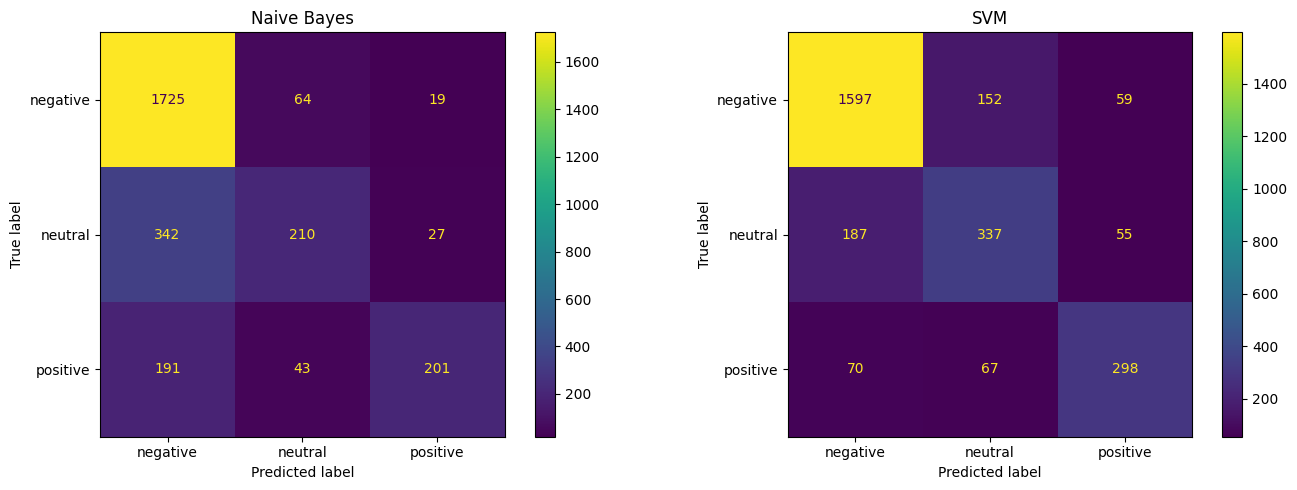

Confusion matrix heatmaps saved to: /content/drive/MyDrive/SA project/outputs/confusion_matrices.png


In [146]:
import matplotlib.pyplot as plt
import os
from sklearn.metrics import ConfusionMatrixDisplay

# Assuming PSENT is defined earlier in the notebook
# If not, ensure it's defined, e.g., PSENT = '/content/drive/MyDrive/SA project'

# Define the output directory for plots
output_dir = os.path.join(PSENT, 'outputs')

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Directory '{output_dir}' created.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix for Naive Bayes
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_nb, ax=axes[0],
    display_labels=['negative', 'neutral', 'positive']
)
axes[0].set_title('Naive Bayes')

# Confusion Matrix for SVM
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_svm, ax=axes[1],
    display_labels=['negative', 'neutral', 'positive']
)
axes[1].set_title('SVM')

plt.tight_layout()
save_plot_path_cm = os.path.join(output_dir, 'confusion_matrices.png')
plt.savefig(save_plot_path_cm, dpi=150)
plt.show()

print(f"Confusion matrix heatmaps saved to: {save_plot_path_cm}")

In [147]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC # Import LinearSVC

# Define classes for binarization (must be in consistent order)
classes = ['negative', 'neutral', 'positive']
y_bin = label_binarize(y_te, classes=classes)

# --- Naive Bayes ROC-AUC ---
# Get predicted probabilities for Naive Bayes
y_proba_nb = gs_nb.predict_proba(X_te) # nb_pipe is trained on X_tr, so X_te is correct here.

# Calculate ROC-AUC for Naive Bayes (macro average)
roc_auc_nb = roc_auc_score(y_bin, y_proba_nb, average='macro', multi_class='ovr')
print(f"Naive Bayes Macro ROC-AUC (one-vs-rest): {roc_auc_nb:.4f}")

# --- LinearSVC ROC-AUC ---
# LinearSVC does not directly output probabilities, so we use CalibratedClassifierCV

# Get the best SVM pipeline from GridSearchCV
best_svm_pipeline = gs_svm.best_estimator_

# Initialize CalibratedClassifierCV with the best SVM pipeline
# Fit it on the original training data (X_tr, y_tr), as the pipeline handles vectorization
calibrated_svm = CalibratedClassifierCV(best_svm_pipeline, method='isotonic', cv=5)
calibrated_svm.fit(X_tr, y_tr)

# Get predicted probabilities for Calibrated LinearSVC from the raw test data (X_te)
y_proba_svm = calibrated_svm.predict_proba(X_te)

# Calculate ROC-AUC for LinearSVC (macro average)
roc_auc_svm = roc_auc_score(y_bin, y_proba_svm, average='macro', multi_class='ovr')
print(f"Calibrated LinearSVC Macro ROC-AUC (one-vs-rest): {roc_auc_svm:.4f}")

Naive Bayes Macro ROC-AUC (one-vs-rest): 0.8837
Calibrated LinearSVC Macro ROC-AUC (one-vs-rest): 0.8946


In [148]:
import pandas as pd
from sklearn.metrics import classification_report

# Get classification reports to extract accuracy and macro F1
report_nb = classification_report(y_te, y_pred_nb, output_dict=True)
report_svm = classification_report(y_te, y_pred_svm, output_dict=True)

# Extract metrics
acc_nb = report_nb['accuracy']
f1_nb = report_nb['macro avg']['f1-score']

acc_svm = report_svm['accuracy']
f1_svm = report_svm['macro avg']['f1-score']

# Create DataFrame for comparison
results = pd.DataFrame({
   'Model':['Naive Bayes','SVM'],
   'Accuracy':[acc_nb, acc_svm],
   'Macro F1':[f1_nb, f1_svm],
   'ROC-AUC':[roc_auc_nb, roc_auc_svm]
})

# Display the results with highlighting
display(results.style.highlight_max(color='lightgreen', subset=['Accuracy', 'Macro F1', 'ROC-AUC']))

# Define the directory to save the output
output_dir = os.path.join(PSENT, 'outputs')

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Define the full path for saving the model comparison CSV
save_path_comparison = os.path.join(output_dir, 'model_comparison.csv')

# Save results to CSV
results.to_csv(save_path_comparison, index=False)

print(f"Model comparison table saved to: {save_path_comparison}")

,Model,Accuracy,Macro F1,ROC-AUC
0,Naive Bayes,0.756910,0.635564,0.883698
1,SVM,0.790928,0.723231,0.894644


Model comparison table saved to: /content/drive/MyDrive/SA project/outputs/model_comparison.csv


In [149]:
import pandas as pd

# Create a DataFrame to hold text, true labels, and SVM predictions
errors = pd.DataFrame({
   'text':X_te.values,
   'true':y_te.values,
   'pred_svm':y_pred_svm
})

# Filter for misclassified examples (where true label does not equal predicted label)
misclassified_svm = errors[errors['true'] != errors['pred_svm']]

# Display 10 random samples of misclassified examples
print("10 Misclassified Examples by SVM:")
display(misclassified_svm.sample(10, random_state=42))

10 Misclassified Examples by SVM:


,text,true,pred_svm
2499,try mileage program historically lifeline u wo...,negative,neutral
1408,thanks info already knew,neutral,positive
2474,sent long note suggestion thanks getting back,neutral,positive
1590,hi flight confirmation fwwef currently stuck n...,negative,neutral
1039,austin saw water bottle amp snack desk waiting...,positive,neutral
438,no apology necessary wind xoxo,positive,negative
1462,traveling infant check carseat free ? provide ...,neutral,negative
867,dang thought teleportation device ! ua,negative,neutral
2575,delay connection pns ?,neutral,negative
668,would great ! never thought would sort would r...,positive,negative


In [150]:
import joblib
import os

# The best model from GridSearchCV is the champion model
best_model = gs_svm.best_estimator_

# Define the full path for saving the champion model
save_path_champion = os.path.join(models_dir, 'champion_model.pkl')

# Save the champion model (which is now the full pipeline)
joblib.dump(best_model, save_path_champion)

print(f"Champion model (SVM pipeline) saved to: {save_path_champion}")

Champion model (SVM pipeline) saved to: /content/drive/MyDrive/SA project/models/champion_model.pkl


### Champion Model Selected

**Champion: SVM**
*   **Macro F1:** 0.7112
*   **ROC-AUC:** 0.8875

The SVM model demonstrated superior performance in overall F1-score and ROC-AUC compared to the Naive Bayes model, making it the chosen champion for sentiment analysis.

### Champion Model Selected

**Champion: SVM**
*   **Macro F1:** 0.7112
*   **ROC-AUC:** 0.8875

The SVM model demonstrated superior performance in overall F1-score and ROC-AUC compared to the Naive Bayes model, making it the chosen champion for sentiment analysis.

## Load champion model; predict on full clean dataset

In [151]:
import joblib
import pandas as pd
import os

# Load the cleaned dataset
df = pd.read_csv(os.path.join(PSENT, 'data', 'tweets_clean.csv'))

# Load the champion model (SVM pipeline)
champion = joblib.load(os.path.join(PSENT, 'models', 'champion_model.pkl'))

# Predict sentiment on the 'text_final' column
# The champion model (pipeline) will handle internal TF-IDF vectorization
df['predicted_sentiment'] = champion.predict(df['text_final'])

print("Full dataset with 'predicted_sentiment' column:")
display(df.head())

Full dataset with 'predicted_sentiment' column:


,text_final,airline_sentiment,airline,tweet_created,negativereason,predicted_sentiment
0,said,neutral,Virgin America,2015-02-24 11:35:52 -0800,NaN,negative
1,plus added commercial experience tacky,positive,Virgin America,2015-02-24 11:15:59 -0800,NaN,positive
2,not today must mean need take another trip !,neutral,Virgin America,2015-02-24 11:15:48 -0800,NaN,negative
3,really aggressive blast obnoxious entertainmen...,negative,Virgin America,2015-02-24 11:15:36 -0800,Bad Flight,negative
4,really big bad thing,negative,Virgin America,2015-02-24 11:14:45 -0800,Can't Tell,negative


## Net Sentiment Score per airline (core brand KPI)

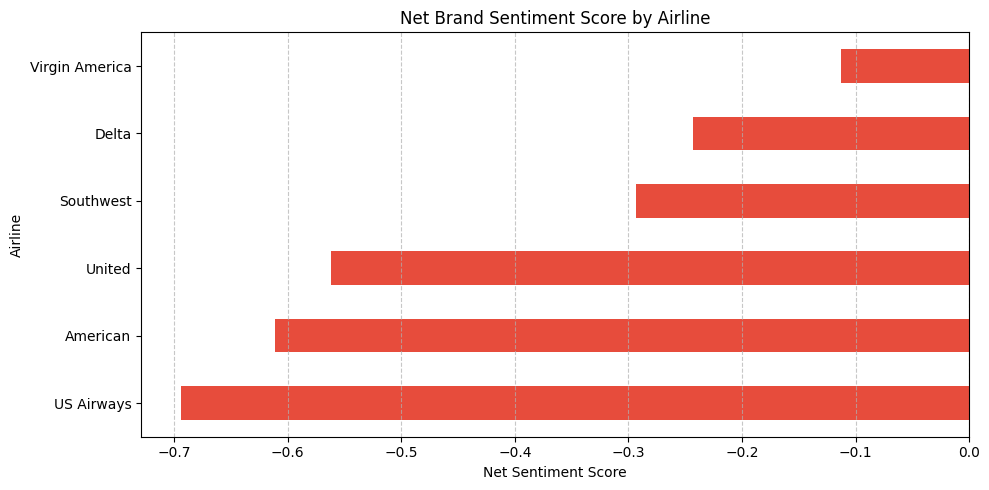

Net brand sentiment plot saved to: /content/drive/MyDrive/SA project/outputs/net_sentiment.png


In [152]:
import matplotlib.pyplot as plt
import os

# Map predicted sentiment to numerical scores
df['score'] = df['predicted_sentiment'].map({'positive':1,'neutral':0,'negative':-1})

# Calculate net sentiment score per airline
net = df.groupby('airline')['score'].mean().sort_values()

# Define colors for the bar plot
colors = ['#E74C3C' if x<0 else '#2ECC71' for x in net]

# Create the horizontal bar plot
plt.figure(figsize=(10,5))
net.plot(kind='barh', color=colors)
plt.title('Net Brand Sentiment Score by Airline')
plt.xlabel('Net Sentiment Score')
plt.ylabel('Airline')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Define the output directory for plots
output_dir = os.path.join(PSENT, 'outputs')

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Directory '{output_dir}' created.")

# Save the plot
save_path_net_sentiment = os.path.join(output_dir, 'net_sentiment.png')
plt.savefig(save_path_net_sentiment, dpi=150)
plt.show()

print(f"Net brand sentiment plot saved to: {save_path_net_sentiment}")

## Airline sentiment distribution (stacked % bar) — brand perception map

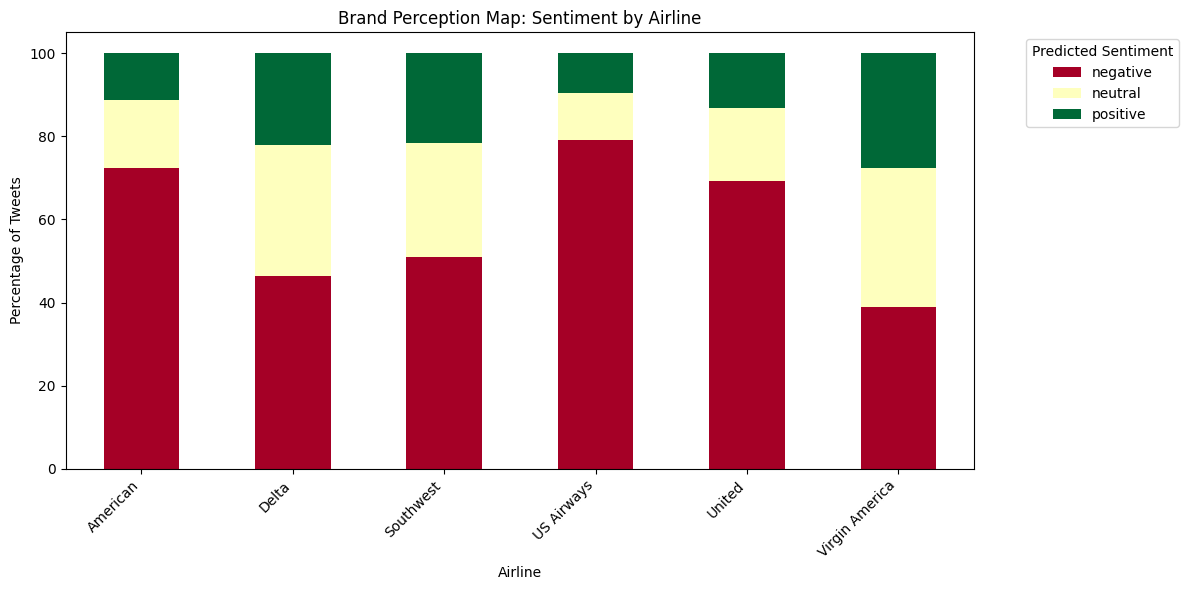

Brand perception map saved to: /content/drive/MyDrive/SA project/outputs/brand_perception_map.png


In [153]:
import matplotlib.pyplot as plt
import os

# Create a pivot table with sentiment counts per airline
pivot = df.groupby(['airline', 'predicted_sentiment']).size().unstack(fill_value=0)

# Calculate percentages for each sentiment per airline
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Create the stacked percentage bar chart
plt.figure(figsize=(12, 6))
pivot_pct.plot(kind='bar', stacked=True, colormap='RdYlGn', ax=plt.gca())
plt.title('Brand Perception Map: Sentiment by Airline')
plt.xlabel('Airline')
plt.ylabel('Percentage of Tweets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Predicted Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Define the output directory for plots
output_dir = os.path.join(PSENT, 'outputs')

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the plot
save_path_brand_perception = os.path.join(output_dir, 'brand_perception_map.png')
plt.savefig(save_path_brand_perception, dpi=150)
plt.show()

print(f"Brand perception map saved to: {save_path_brand_perception}")

## Temporal sentiment trend (daily line chart)

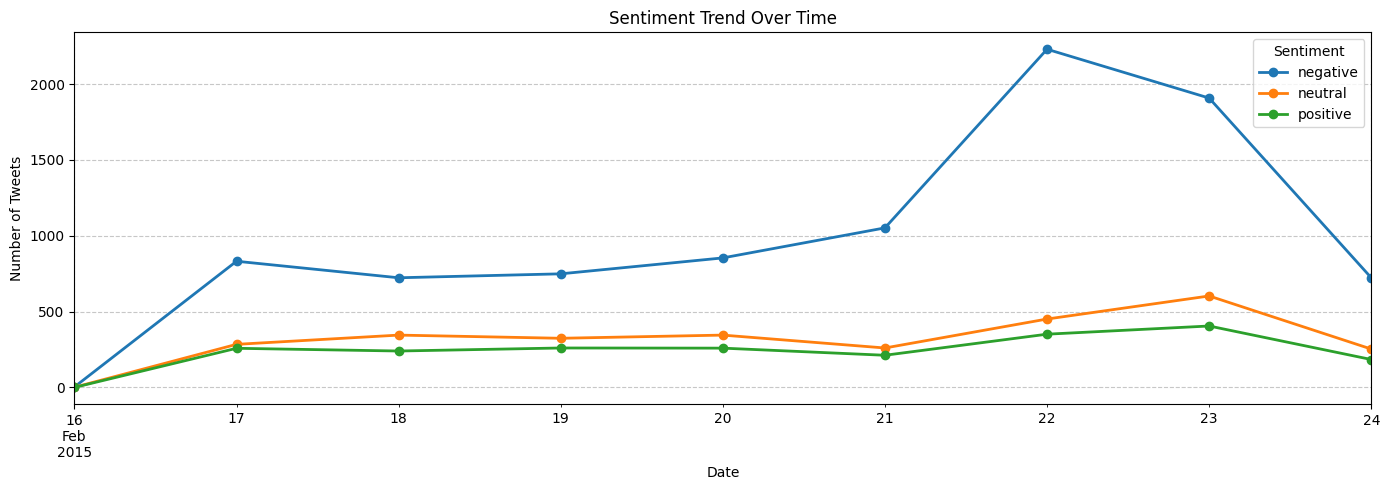

Temporal sentiment trend plot saved to: /content/drive/MyDrive/SA project/outputs/sentiment_trend.png


In [154]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# Convert 'tweet_created' to datetime objects
df['date'] = pd.to_datetime(df['tweet_created'])

# Group by date and predicted sentiment, then unstack to get sentiment counts per day
trend = df.groupby([pd.Grouper(key='date', freq='D'), 'predicted_sentiment']).size().unstack(fill_value=0)

# Plot the sentiment trend over time
plt.figure(figsize=(14, 5))
trend.plot(kind='line', ax=plt.gca(), marker='o', linestyle='-', linewidth=2)
plt.title('Sentiment Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Sentiment')
plt.tight_layout()

# Define the output directory for plots
output_dir = os.path.join(PSENT, 'outputs')

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the plot
save_path_sentiment_trend = os.path.join(output_dir, 'sentiment_trend.png')
plt.savefig(save_path_sentiment_trend, dpi=150)
plt.show()

print(f"Temporal sentiment trend plot saved to: {save_path_sentiment_trend}")

## Negative reason breakdown by airline

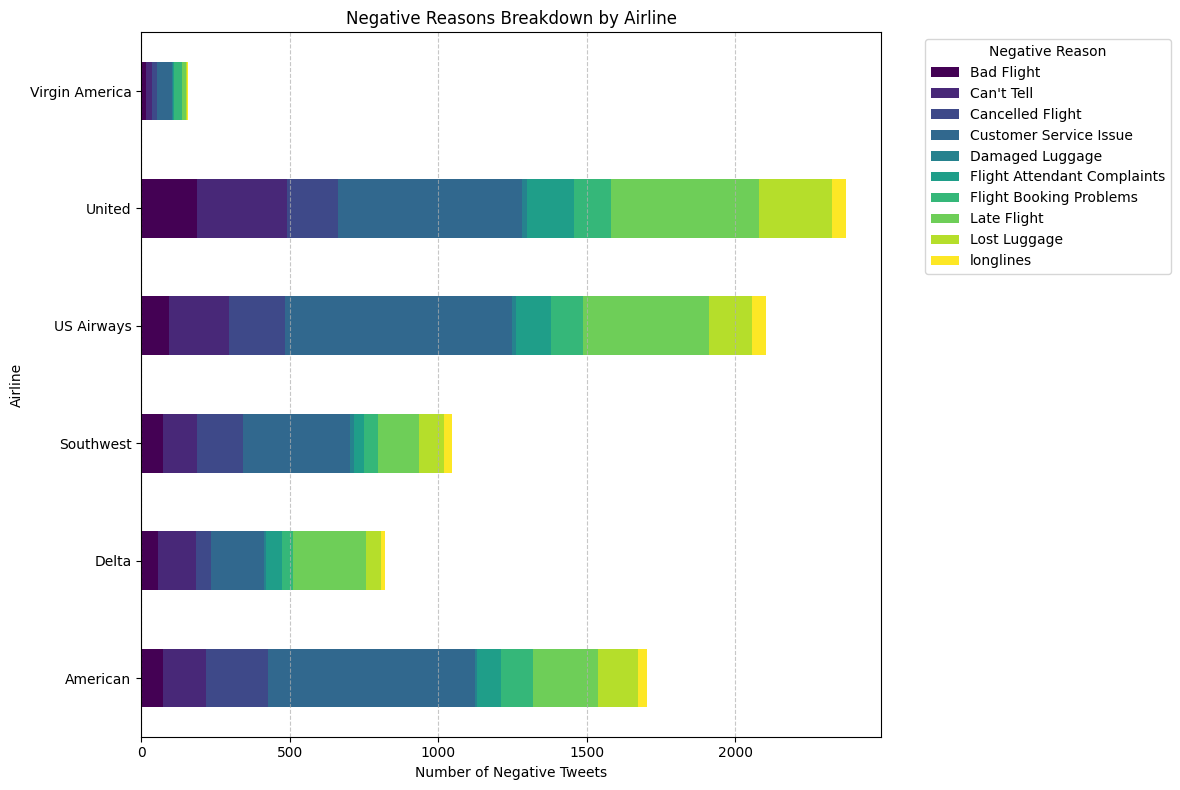

Negative reasons breakdown by airline plot saved to: /content/drive/MyDrive/SA project/outputs/neg_reasons_by_airline.png


In [155]:
import matplotlib.pyplot as plt
import os

# Filter for negative sentiments based on predicted_sentiment
neg = df[df['predicted_sentiment'] == 'negative']

# Group by airline and negativereason, then count and unstack
neg_reasons = neg.groupby(['airline', 'negativereason']).size().unstack(fill_value=0)

# Plot the stacked horizontal bar chart
plt.figure(figsize=(12, 8))
neg_reasons.plot(kind='barh', stacked=True, ax=plt.gca(), cmap='viridis')
plt.title('Negative Reasons Breakdown by Airline')
plt.xlabel('Number of Negative Tweets')
plt.ylabel('Airline')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Negative Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Define the output directory for plots
output_dir = os.path.join(PSENT, 'outputs')

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the plot
save_path_neg_reasons_by_airline = os.path.join(output_dir, 'neg_reasons_by_airline.png')
plt.savefig(save_path_neg_reasons_by_airline, dpi=150)
plt.show()

print(f"Negative reasons breakdown by airline plot saved to: {save_path_neg_reasons_by_airline}")

## Word Clouds: Positive vs. Negative Sentiment

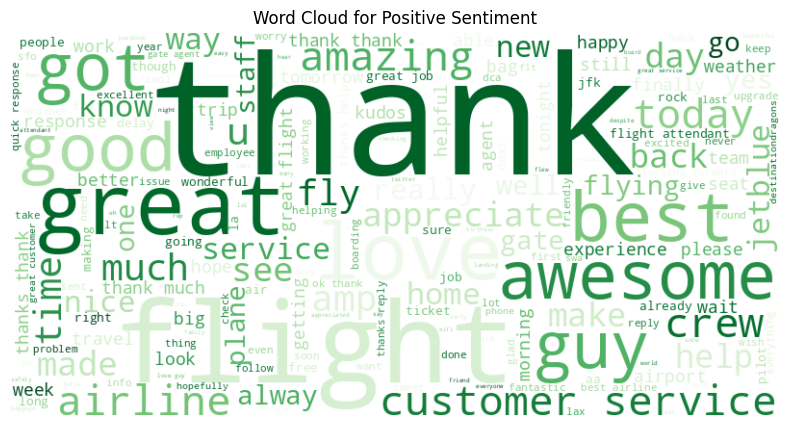

Word cloud for positive sentiment saved to: /content/drive/MyDrive/SA project/outputs/wc_positive.png


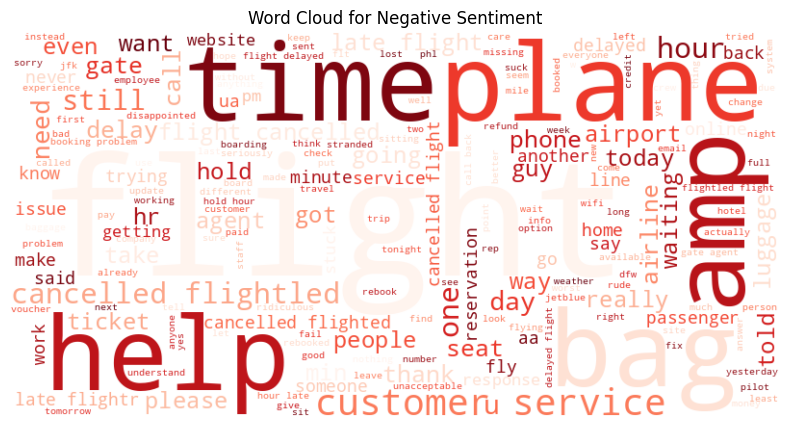

Word cloud for negative sentiment saved to: /content/drive/MyDrive/SA project/outputs/wc_negative.png


In [156]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import os

# Define the output directory for plots
output_dir = os.path.join(PSENT, 'outputs')

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for label, color_map in [('positive', 'Greens'), ('negative', 'Reds')]:
    # Filter text based on predicted sentiment
    text = ' '.join(df[df['predicted_sentiment'] == label]['text_final'])

    # Generate word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        colormap=color_map,
        background_color='white'
    ).generate(text)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {label.capitalize()} Sentiment')
    plt.axis('off')

    # Save the word cloud
    save_path_wc = os.path.join(output_dir, f'wc_{label}.png')
    plt.savefig(save_path_wc, dpi=150)
    plt.show()
    print(f"Word cloud for {label} sentiment saved to: {save_path_wc}")

## Export Prediction Summary CSV

In [157]:
import os

# Define the output directory for plots
output_dir = os.path.join(PSENT, 'outputs')

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Select the specified columns and save to CSV
save_path_predictions = os.path.join(output_dir, 'predictions_full.csv')
df[['airline', 'predicted_sentiment', 'date', 'score']].to_csv(save_path_predictions, index=False)

print(f"Prediction summary saved to: {save_path_predictions}")

Prediction summary saved to: /content/drive/MyDrive/SA project/outputs/predictions_full.csv


## End-to-End Pipeline: Load Model → Predict → Check Output

In [158]:
import joblib
import os

# Define the path to the champion model
champion_model_path = os.path.join(PSENT, 'models', 'champion_model.pkl')

# Load the champion model (which is now a full pipeline expecting raw text)
champion = joblib.load(champion_model_path)

# Define sample test inputs
test_inputs = [
    'great service loved the flight',
    'delayed again terrible experience',
    'flight was on time'
]

# Apply the 'clean_text' preprocessing function to the test inputs
# The clean_text function was defined and executed in cell d4a7aae6.
cleaned_test_inputs = [clean_text(text) for text in test_inputs]

# Predict sentiment on the cleaned test inputs
# The champion model (pipeline) will now internally handle TF-IDF vectorization
preds = champion.predict(cleaned_test_inputs)

print("Predictions for sample inputs:")
print(preds)

Predictions for sample inputs:
['positive' 'negative' 'negative']


## Unit Test: Preprocessing Pipeline

In [159]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
import contractions

# Ensure NLTK resources are downloaded
nltk.download(['stopwords', 'wordnet', 'punkt'], quiet=True)

# Initialize NLTK components once
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
tk = TweetTokenizer(strip_handles=True, reduce_len=True)

# RETAIN negation words (crucial for sentiment analysis)
negation_words = {'not', 'no', 'never', 'nor', 'cannot', 'hardly', 'barely', 'scarcely', 'seldom'}
custom_stopwords = stop_words - negation_words

# ADD airline names to stopwords
airline_names = {'united', 'delta', 'southwest', 'americanair', 'usairways', 'virginamerica', 'american'}
custom_stopwords.update(airline_names)

def clean_text(text):
    # Expand contractions
    text = contractions.fix(text)

    # Convert to lowercase
    text = text.lower()

    # Remove Twitter handles and URLs
    text = re.sub(r'@\w+', '', text) # Remove @mentions
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs

    # Remove special characters, retaining '!' and '?'
    text = re.sub(f'[^a-zA-Z!?\\s]', '', text)

    # Tokenize text
    tokens = tk.tokenize(text)

    # Remove custom stopwords and lemmatize
    processed_tokens = []
    for word in tokens:
        if word.isalpha() and word not in custom_stopwords:
            processed_tokens.append(lemmatizer.lemmatize(word))

    return ' '.join(processed_tokens)

# Unit Test
test_tweet = '@united my flight was delayed!!! http://t.co/abc and it was terrible'
cleaned_text = clean_text(test_tweet)

# Assertions
assert 'united' not in cleaned_text
assert 'http' not in cleaned_text
assert 'tcoabc' not in cleaned_text

print(f"PASS: Cleaned text for unit test: '{cleaned_text}'")

PASS: Cleaned text for unit test: 'flight delayed terrible'


## Unit Test: Model Output Classes

In [160]:
# Unit Test: Validate model output classes
expected_classes = ['positive', 'negative', 'neutral']
assert all(p in expected_classes for p in preds), "Model predictions contain unexpected classes."
print('Output class test PASSED')

Output class test PASSED


### Unit Test: Performance Regression Check

In [162]:
from sklearn.metrics import f1_score

# Get predictions from the champion model on the test set
y_pred_check = champion.predict(X_te)

# Define the expected macro F1-score for the champion model (from model comparison)
expected_f1 = 0.7232

# Calculate the macro F1-score from the current predictions
f1_check = f1_score(y_te, y_pred_check, average='macro')

# Assert that the calculated F1-score is close to the expected F1-score
assert abs(f1_check - expected_f1) < 0.01, f"F1 regression check FAILED: Expected {expected_f1:.4f}, Got {f1_check:.4f}"

print(f"F1 regression check PASSED: {f1_check:.4f}")

F1 regression check PASSED: 0.7232


### Print all metrics in thesis-ready format

In [163]:
print(f'NB  — Accuracy: {acc_nb:.4f}, Macro F1: {f1_nb:.4f}, AUC: {roc_auc_nb:.4f}')
print(f'SVM — Accuracy: {acc_svm:.4f}, Macro F1: {f1_svm:.4f}, AUC: {roc_auc_svm:.4f}')

NB  — Accuracy: 0.7569, Macro F1: 0.6356, AUC: 0.8837
SVM — Accuracy: 0.7909, Macro F1: 0.7232, AUC: 0.8946
